In [1]:
import pandas as pd
import matplotlib .pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
import joblib 
import numpy as np
import seaborn as sns

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/Clusterizacao-dados-sem-rotulo/main/Dados/dados_mkt.csv'

#### Objetivo 

- Construir um modelo de ML que consiga segmentar os usuários por grupos com base em seus interesses comuns para fornecer insights para um time de marketing criar campanhas mais eficazes

# Coletando e ajustando dados

In [3]:
# Dados não rotulados

df = pd.read_csv(url)
df

,sexo,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,...,musica,rock,cabelo,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas
0,F,27,49,0,0,10,0,0,10,0,...,0,0,0,0,0,0,0,0,0,10
1,F,27,41,0,0,0,0,0,0,0,...,10,20,40,0,10,0,0,0,0,10
2,F,26,1,0,0,0,0,0,10,0,...,10,0,50,0,0,0,30,0,0,0
3,M,28,32,0,50,0,0,0,0,0,...,10,10,0,0,0,0,0,0,0,0
4,M,28,18,0,0,0,0,0,0,0,...,0,0,0,0,0,0,10,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12987,F,26,21,0,0,0,0,0,0,0,...,0,10,10,0,0,0,20,0,0,0
12988,F,26,50,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12989,F,27,32,0,0,0,0,0,0,10,...,0,0,0,0,0,0,0,0,0,0
12990,F,27,20,0,0,0,0,0,0,0,...,10,0,0,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12992 entries, 0 to 12991
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sexo               12992 non-null  object
 1   idade              12992 non-null  int64 
 2   numero_de_amigos   12992 non-null  int64 
 3   basquete           12992 non-null  int64 
 4   futebol_americano  12992 non-null  int64 
 5   futebol            12992 non-null  int64 
 6   softbol            12992 non-null  int64 
 7   voleibol           12992 non-null  int64 
 8   natacao            12992 non-null  int64 
 9   animacao           12992 non-null  int64 
 10  beisebol           12992 non-null  int64 
 11  tenis              12992 non-null  int64 
 12  esportes           12992 non-null  int64 
 13  fofo               12992 non-null  int64 
 14  danca              12992 non-null  int64 
 15  banda              12992 non-null  int64 
 16  marcha             12992 non-null  int64

In [5]:
# Conhecendo uma coluna categória
df['sexo'].unique()

array(['F', 'M', 'NE'], dtype=object)

## Aplicando encoder

In [6]:
encoder = OneHotEncoder(categories=[['F', 'M', 'NE']], sparse_output=False)

In [7]:
encoded_sexo = encoder.fit_transform(df[['sexo']])
encoded_sexo

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]], shape=(12992, 3))

In [8]:
encoded_df = pd.DataFrame(encoded_sexo, columns=encoder.get_feature_names_out(['sexo']))

In [9]:
dados = pd.concat([df,encoded_df], axis=1).drop('sexo', axis=1)
dados

,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,beisebol,...,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas,sexo_F,sexo_M,sexo_NE
0,27,49,0,0,10,0,0,10,0,0,...,0,0,0,0,0,0,10,1.0,0.0,0.0
1,27,41,0,0,0,0,0,0,0,10,...,0,10,0,0,0,0,10,1.0,0.0,0.0
2,26,1,0,0,0,0,0,10,0,0,...,0,0,0,30,0,0,0,1.0,0.0,0.0
3,28,32,0,50,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.0,1.0,0.0
4,28,18,0,0,0,0,0,0,0,0,...,0,0,0,10,0,0,0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12987,26,21,0,0,0,0,0,0,0,0,...,0,0,0,20,0,0,0,1.0,0.0,0.0
12988,26,50,0,0,0,0,0,0,0,10,...,0,0,0,0,0,0,0,1.0,0.0,0.0
12989,27,32,0,0,0,0,0,0,10,0,...,0,0,0,0,0,0,0,1.0,0.0,0.0
12990,27,20,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0.0,0.0


In [10]:
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']

## Desenvolvendo o modelo

In [11]:
mod_kmeans = KMeans(n_clusters=2, random_state=45)

In [12]:
modelo = mod_kmeans.fit(dados)

C:\Users\luizf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\luizf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^

- Identificar e lidar com dados sem rótulo usando Pandas em Python;
- Selecionar o tipo de modelo de Machine Learning para dados sem rótulo;
- Aplicar a técnica de codificação One-hot para transformar variáveis categóricas em numéricas;
- Criar e treinar um modelo K-means.

# Avaliando o K-means

In [13]:
mod_kmeans.inertia_

24912957.594588563

In [14]:
from sklearn.metrics import silhouette_score

silhouette_score(dados, mod_kmeans.predict(dados))

np.float64(0.3799715886302017)

## Avaliando métricas para diferentes K

In [15]:

def avaliacao(dados):
    inercia = []
    silhueta = []
    
    for k in range(2,21):
        kmeans = KMeans(n_clusters=k, random_state=45, n_init='auto')
        kmeans.fit(dados)
        inercia.append(kmeans.inertia_)
        silhueta.append(f"k={k} - " + str(silhouette_score(dados, kmeans.predict(dados)))) 

    return silhueta, inercia

In [16]:
silhueta, inercia = avaliacao(dados)
silhueta

['k=2 - 0.3799715886302017',
 'k=3 - 0.2631947012216279',
 'k=4 - 0.27497370057197046',
 'k=5 - 0.2762790287828939',
 'k=6 - 0.2814107923103627',
 'k=7 - 0.19566339131554092',
 'k=8 - 0.12271514125212872',
 'k=9 - 0.1281093701405103',
 'k=10 - 0.13020718009107704',
 'k=11 - 0.13209306347804026',
 'k=12 - 0.09015815350273831',
 'k=13 - 0.09002551845716941',
 'k=14 - 0.08959066111262458',
 'k=15 - 0.09427696863257996',
 'k=16 - 0.09552364235312874',
 'k=17 - 0.09543714624178481',
 'k=18 - 0.08844412672288283',
 'k=19 - 0.0844173588143633',
 'k=20 - 0.08484109789709748']

## Aula 2.3 - Verificando a silhueta por amostras

In [17]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

def graf_silhueta (n_clusters, dados):

  # Aplica o KMeans ao conjunto de dados
  kmeans = KMeans(n_clusters=n_clusters, random_state=45, n_init = 'auto')
  cluster_previsoes = kmeans.fit_predict(dados)

  # Calcula o silhouette score médio
  silhueta_media = silhouette_score(dados, cluster_previsoes)
  print(f'Valor médio para {n_clusters} clusters: {silhueta_media:.3f}')

  # Calcula a pontuação de silhueta para cada amostra
  silhueta_amostra = silhouette_samples(dados, cluster_previsoes)

  # Configuração da figura para o gráfico de silhueta
  fig, ax1 = plt.subplots(1, 1)
  fig.set_size_inches(9, 7)

  # Limites do gráfico de silhueta
  ax1.set_xlim([-0.1, 1])
  ax1.set_ylim([0, len(dados) + (n_clusters + 1) * 10])

  y_lower = 10
  for i in range(n_clusters):
      ith_cluster_silhueta_amostra = silhueta_amostra[cluster_previsoes == i]
      ith_cluster_silhueta_amostra.sort()

      tamanho_cluster_i = ith_cluster_silhueta_amostra.shape[0]
      y_upper = y_lower + tamanho_cluster_i

      cor = cm.nipy_spectral(float(i) / n_clusters)
      ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhueta_amostra,
                        facecolor=cor, edgecolor=cor, alpha=0.7)

      ax1.text(-0.05, y_lower + 0.5 * tamanho_cluster_i, str(i))
      y_lower = y_upper + 10  # 10 para o espaço entre gráficos

  # Linha vertical para a média do Silhouette Score
  ax1.axvline(x=silhueta_media, color='red', linestyle='--')

  ax1.set_title(f'Gráfico da Silhueta para {n_clusters} clusters')
  ax1.set_xlabel('Valores do coeficiente de silhueta')
  ax1.set_ylabel('Rótulo do cluster')

  ax1.set_yticks([])  # Remove os ticks do eixo y
  ax1.set_xticks([i/10.0 for i in range(-1, 11)])

  plt.show()

Valor médio para 2 clusters: 0.380


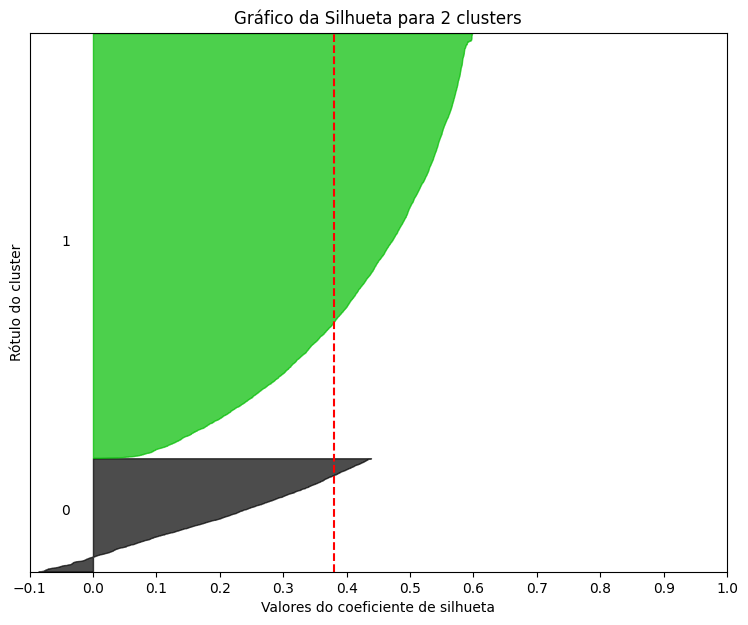

In [18]:
graf_silhueta(2,dados)

### Outras visualizações

In [19]:
def plot_cotovelo(inercia):
    plt.figure(figsize=(8,4))
    plt.plot(range(2,21), inercia,'bo-')

    plt.xlabel('número de clusters')
    plt.ylabel('inércia')
    plt.xlabel('Método colovelo para determinação de K')

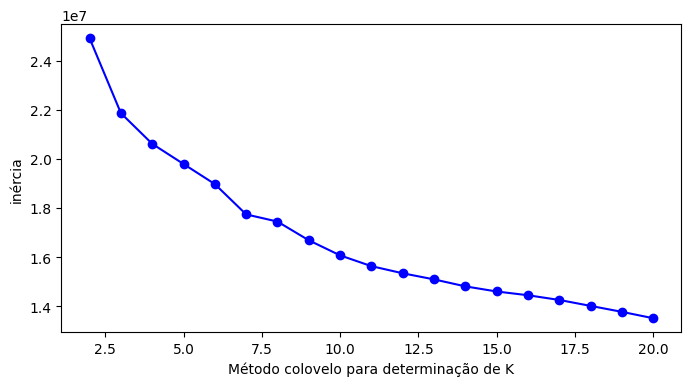

In [20]:
plot_cotovelo(inercia)

- Avaliar a qualidade dos clusters usando as métricas de inércia e silhueta;
- Treinar e avaliar o modelo K-Means com diferentes números de clusters;
- Analisar a distribuição de valores de silhueta com silhouette_samples;
- Explorar o método cotovelo para determinar a quantidade ideal de clusters.

# Avaliação e ajuste de dados

In [21]:
# O modelo de Dados Kmenas é sensível a escala e vemos uma discrepância muito grande entre estre os vaalores de cada atributo
dados.describe()

,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,beisebol,...,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas,sexo_F,sexo_M,sexo_NE
count,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,...,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000
mean,26.852679,31.283790,3.063424,2.927186,2.536946,1.836515,1.641010,1.548645,1.207666,1.198430,...,1.340055,2.977986,4.094828,1.720289,0.819735,0.589594,1.050647,0.761469,0.166256,0.072275
std,1.203746,35.891178,8.374443,7.431099,9.810703,7.881526,6.818708,5.862203,5.376673,5.558905,...,4.934874,7.479126,7.670547,5.092112,3.799795,2.999547,4.492218,0.426202,0.372325,0.258953
min,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,27.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,28.000000,45.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,30.000000,605.000000,220.000000,90.000000,220.000000,170.000000,140.000000,310.000000,80.000000,140.000000,...,70.000000,120.000000,110.000000,80.000000,80.000000,80.000000,80.000000,1.000000,1.000000,1.000000


In [25]:
#Aplicamos um scaler que irá normalizar os dados de modo a facilitar a definição de qual dado pertence a determinado cluster

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

dados_escalados = scaler.fit_transform(dados)
dados_escalados

array([[0.66666667, 0.08099174, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.66666667, 0.0677686 , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.55555556, 0.00165289, 0.        , ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.66666667, 0.05289256, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.66666667, 0.03305785, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.44444444, 0.04132231, 0.        , ..., 1.        , 0.        ,
        0.        ]], shape=(12992, 29))

In [27]:
#traformação dos dados escalados em matrix para um dataframe

dados_escalados = pd.DataFrame(dados_escalados, columns=dados.columns)

dados_escalados.describe()

,idade,numero_de_amigos,basquete,futebol_americano,futebol,softbol,voleibol,natacao,animacao,beisebol,...,vestido,shopping,compras,roupas,nossa_marca,marca_concorrente,bebidas,sexo_F,sexo_M,sexo_NE
count,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,...,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000,12992.000000
mean,0.650298,0.051709,0.013925,0.032524,0.011532,0.010803,0.011721,0.004996,0.015096,0.008560,...,0.019144,0.024817,0.037226,0.021504,0.010247,0.007370,0.013133,0.761469,0.166256,0.072275
std,0.133750,0.059324,0.038066,0.082568,0.044594,0.046362,0.048705,0.018910,0.067208,0.039706,...,0.070498,0.062326,0.069732,0.063651,0.047497,0.037494,0.056153,0.426202,0.372325,0.258953
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.555556,0.008264,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.666667,0.034711,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.777778,0.074380,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.090909,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
# disponibilaremos os dados posteriormente através do arquivo.pkl

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Verificando as métricas para os novos dados

In [31]:
silhueta, inercia = avaliacao(dados_escalados)

In [32]:
silhueta


['k=2 - 0.6684575483061148',
 'k=3 - 0.7447500875317523',
 'k=4 - 0.30530680533895693',
 'k=5 - 0.3074446810629103',
 'k=6 - 0.3112387030023592',
 'k=7 - 0.3085860859611137',
 'k=8 - 0.319777962428705',
 'k=9 - 0.22706218374995277',
 'k=10 - 0.22472400849594734',
 'k=11 - 0.22798574383673903',
 'k=12 - 0.22555027549761011',
 'k=13 - 0.1618579533303784',
 'k=14 - 0.1629865017307575',
 'k=15 - 0.16552254369386465',
 'k=16 - 0.16673895280847542',
 'k=17 - 0.16384282247396845',
 'k=18 - 0.16521943288325647',
 'k=19 - 0.1652810286868148',
 'k=20 - 0.1500107504422225']

Valor médio para 3 clusters: 0.745


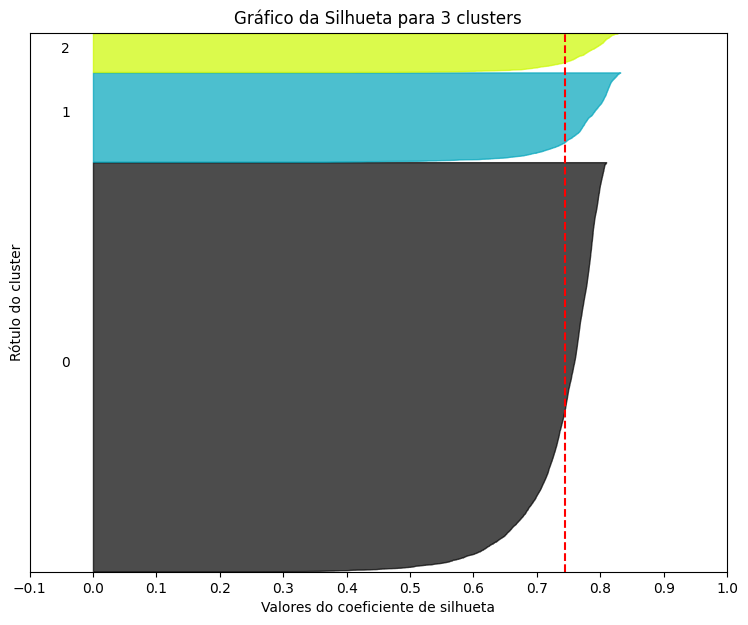

In [33]:
graf_silhueta(3, dados_escalados)

## Criando o melhor modelo

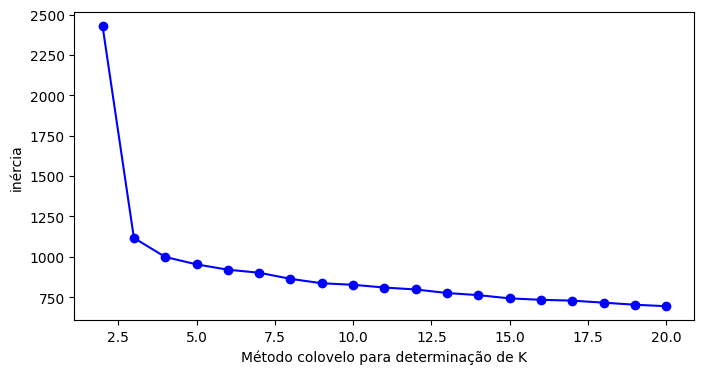

In [35]:
plot_cotovelo(inercia)

In [37]:
modelo_kmeans = KMeans(n_clusters=3,random_state=45, n_init='auto')

modelo_kmeans.fit(dados_escalados)

KMeans(n_clusters=3, random_state=45)

In [38]:
joblib.dump(modelo_kmeans, 'kmeans_scaler.plk')

['kmeans_scaler.plk']

# Analisando as informações de cada cluster

## Descrevendo cada agrupamento